# Laplacian Regularized Graph-Bandit
We implement the paper of Yang et al 2020, which is a multi-task bandit paper

In [1]:
import numpy as np
from math import sqrt, log
from matplotlib import pyplot as plt
from numpy.random import default_rng
random = default_rng()
from tqdm import tqdm
from policy import GraphLinUCB
from bandit import MultiTaskContextualBandit
from experiment import bandit_multitask_experiment
import utils

## Parameters
We follow the simulated data generation of the algorithm's paper

## Bandit experiment
We generate a graph and we carry out repetitions for the bandit experiment.

In [2]:
n_users = 10
dim = 5
n_arms= 500

Adj = utils.generate_graph(n_users, p= 0.4)
L = utils.random_walk_laplacian(Adj)



Theta_0 = random.standard_normal(size=(n_users, dim))
gamma = 7.0
Theta = np.linalg.solve(np.eye(n_users) + gamma*0.5*(L.T+L),  Theta_0)
# Theta = np.linalg.solve(np.eye(n_users) + gamma*0.5*(L.T+L),  Theta_0)/sqrt(dim)

Theta /= np.linalg.norm(Theta, axis= 1, keepdims= True)




# def context_sampler(dim, n_arms, random_generator):
#     X =  random_generator.random(size= (n_arms, dim))/sqrt(dim)
#     return X# / np.linalg.norm(X, axis= 1, keepdims= True)
X =  random.standard_normal(size= (n_arms, dim))
X /= np.linalg.norm(X, axis= 1, keepdims= True)
def context_sampler(dim, n_arms, random_generator):
    return X[np.random.choice(range(len(X)), size= 50)]

horizon = 1000
noise_sampler = random.standard_normal


repetitions = 30

In [3]:
rewards = []
rewards_oracle = []
errors = []
# player = GraphLinUCB_old(a= 1.0, delta= 0.01) 
player = GraphLinUCB(a= 1.0, delta= 0.01) 

for i in tqdm(range(repetitions)):
    bandit = MultiTaskContextualBandit(Theta, n_arms= n_arms, Laplacian= L, context_sampler= context_sampler, 
                                        noise_sampler= noise_sampler, sigma= 0.01, context_generator= 2)
    expected_reward, oracle_expected_reward, Theta_error = bandit_multitask_experiment(bandit, player, horizon= horizon)
    rewards.append(expected_reward)
    rewards_oracle.append(oracle_expected_reward)
    errors.append(Theta_error)
rewards = np.array(rewards).T
rewards_oracle = np.array(rewards_oracle).T
errors = np.array(errors).T

  0%|          | 0/30 [00:00<?, ?it/s]

0.0
0.0
0.08572150000247629
0.0
0.1079709927478718
0.09133798005780955
0.06256160766148426
0.07728827588326598
0.02615974013689581
0.2332903043265449
0.11925823666081198
0.11461723150968044
0.13822885595813306
0.212207401948824
0.18087193876889543
0.12609633510026066
0.12699014353179505
0.12441012510697676
0.16189018806967365
0.28271967180355617
0.16299859529944852
0.17443745520241044
0.23026057317269377
0.2574583465673409
0.22931138043089813
0.17205413141040324
0.19855541134613133
0.17585439053953436
0.19400072263600773
0.25381489263521406
0.20009543866079338
0.22522626397971898
0.24623165377828587
0.2870651844015521
0.26846273836632917
0.1930220373265649
0.2054361668982666
0.20940542018538216
0.24518838559462006
0.27024116105136464
0.2375184734316401
0.20615209493781836
0.22762810120655225
0.3049795981444845
0.28732013963995573
0.21194949306772642
0.21529479142387697
0.22381730467321764
0.263734862125674
0.28496758474923434
0.26000311007227234
0.21391173581810322
0.240026468277267
0.

  3%|▎         | 1/30 [00:00<00:18,  1.54it/s]

0.0729220080243379
0.0582206935002203
0.04715022538676546
0.06861768741532132
0.08632437574412066
0.07152630317214446
0.05787964488193547
0.059524632033356534
0.09825995852651384
0.06879227716049606
0.0728754336580578
0.05760050657383283
0.04687593940125049
0.06701617879276975
0.08491993751433781
0.06916288357074421
0.05762929305930883
0.05918046075113353
0.09720510993686599
0.06831430603325675
0.07282966770708145
0.057479542152921476
0.0462031934588173
0.06652108811298424
0.08458040780614433
0.06839126084978926
0.05750483590908343
0.05888300055409486
0.09683592653855806
0.06766881129777028
0.07278200577616453
0.05736868471388054
0.04606563511231544
0.065756302922228
0.08287400995822235
0.06775946083842634
0.057280031409527664
0.05822261673279247
0.09601837474525111
0.06645296163639527
0.0718960925529759
0.05664921283574288
0.0449940116933799
0.061984035548724004
0.08260177064694389
0.06746850388226734
0.05647125499953871
0.054301492925563834
0.09524838129730544
0.06600828325792914
0.0

  7%|▋         | 2/30 [00:01<00:16,  1.66it/s]

...

 40%|████      | 12/30 [00:06<00:09,  1.84it/s]

0.07799858312282627
0.0651886439677235
0.07223259449997421
0.10539305400032996
0.08306745391943485
0.07547413356222363
0.06973880652293304
0.11814004489983927
0.09242003816753534
0.08143416503063568
0.07270449450702053
0.06341502420327133
0.07200556415056007
0.10425884585301944
0.08101618483236281
0.07458716975140395
0.06804920619406667
0.11751818558579606
0.09231842533769447
0.07885659597854801
0.07190068874404508
0.06286468855576391
0.0716111208614452
0.10402558177217455
0.08092204782728865
0.06981090545725632
0.06734019902862044
0.11651454130573052
0.09185163058123168
0.07772259522600213
0.07126162808724341
0.06262302208389192
0.07039348813534696
0.10251838451883054
0.0736381607066599
0.06834223093979641
0.06707073125307593
0.1161230444375397
0.09152079398996368
0.07734915145866351
0.0671532907395331
0.0624066385429961
0.06858598556313701
0.10050901181188356
0.07150759657683341
0.06712544817493202
0.0668040431553283
0.11586321109810661
0.08790457686255125
0.07686332571172562
0.06673

 40%|████      | 12/30 [00:06<00:10,  1.72it/s]

0.1308879218370336
0.18528908919075454
0.12423138870554634
0.13239093570072996
0.11382267696005784
0.22678471035030925
0.12469031915031853
0.1356919396476599
0.12423368856007166
0.12664197196967278
0.13074409822447025
0.17722080722437805
0.11951384674225596
0.13148937767415794
0.1089922242428751
0.22481548308779445
0.12469686844950584
0.1313282300023699
0.12394331542349148
0.12478511202236768
0.1300886203792189
0.16894213043210263
0.11883494635018407
0.1279296297480696
0.10593097196360293
0.2183255222514932
0.12221818335502696
0.12478589288124294
0.12235875473039604
0.12333951267393035
0.12207800404114154
0.16271592271153607
0.11674083724585206
0.12718663011463144
0.10501407761765112
0.21461774591004407
0.12232426356886766
0.12349557952265604
0.12185002095005208
0.11163941454246945
0.11566222607971775
0.16237340487815125
0.11634090833479413
0.12644948885841414
0.10427184966031207
0.20490624093464715
0.11996277831735112
0.12267415162386092
0.11877597182301626
0.11139959605805166
0.11237

KeyboardInterrupt: 

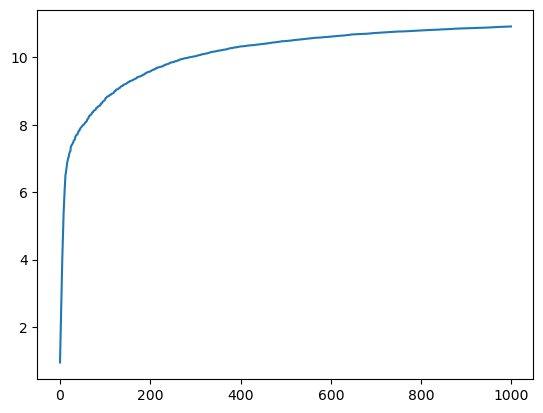

In [ ]:
rewards_cumul = np.cumsum(rewards, axis= 0)
rewards_orcale_cumul = np.cumsum(rewards_oracle, axis= 0)
meanRegret = rewards_orcale_cumul - rewards_cumul
plt.figure()
#plt.plot(meanRegret, 'k', alpha= 0.1);
plt.plot(meanRegret.mean(axis= 1));

### Remarks after the experimental studies
* Initializing the Theta matrix with a normal distribution results in more sublinearity than the case with from uniform random

### Testing the quadratic form of the random walk laplacian

In [30]:
from scipy.spatial.distance  import pdist, squareform


distMat = squareform(pdist(Theta, metric= "sqeuclidean"))


Adj = utils.generate_graph(n_users, p= 0.5)
deg = Adj.sum(axis = 1, keepdims= True)
invDeg = np.where(deg>0, 1/deg, 0.0)
Adj_norm= Adj*invDeg
Adj_norm_sym = 0.5*(Adj_norm + Adj_norm.T)

L = utils.random_walk_laplacian(Adj)
Lap = utils.Laplacian(Adj)
print(f"sums of normalized adjacency rows: {Adj_norm.sum(axis= 1)}")
print(np.trace(Theta.T @ L @ Theta) - 0.5*np.sum(distMat * Adj_norm_sym))

sums of normalized adjacency rows: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
3.3306690738754696e-16


In [31]:
M = random.random((50,50))
# %timeit np.einsum("k, ij-> kij", np.ones(100), M)
# %timeit np.tile(M, (100,1,1))

## Graph Trend Filtering

In [27]:
%timeit a = np.einsum("ji, jk, kl -> il", Theta, L, Theta)
%timeit b = Theta.T @ L @ Theta
a-b

15.5 µs ± 224 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
2.39 µs ± 50.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


array([[ 4.16333634e-17, -6.93889390e-17,  5.55111512e-17,
         1.11022302e-16,  6.93889390e-18],
       [ 0.00000000e+00,  2.77555756e-17,  1.21430643e-17,
        -6.93889390e-17,  1.11022302e-16],
       [ 3.98986399e-17,  0.00000000e+00, -1.38777878e-16,
         1.38344197e-16,  5.55111512e-17],
       [ 1.11022302e-16,  7.28583860e-17,  4.16333634e-17,
        -4.16333634e-17, -2.77555756e-17],
       [ 0.00000000e+00,  5.55111512e-17,  4.16333634e-17,
        -8.32667268e-17,  0.00000000e+00]])

In [4]:
M = random.random((10,10))
M[0, [1,2,4]]

array([0.96499066, 0.92038122, 0.55630883])